#### setup

In [3]:
import sys, os
sys.path.insert(0, "../pointnet")

import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from pointnet_cls     import PointNetCls
from pointnet_dataset import ModelNet40

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = ModelNet40("../../datasets", split="test", num_points=1024, augment=False)
print(f"classes: {dataset.classes}")
print(f"total samples: {len(dataset)}")

modelnet40 already at ../../datasets\modelnet40_ply_hdf5_2048
modelnet40 test: 2468 samples, 40 classes
classes: ['airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair', 'cone', 'cup', 'curtain', 'desk', 'door', 'dresser', 'flower_pot', 'glass_box', 'guitar', 'keyboard', 'lamp', 'laptop', 'mantel', 'monitor', 'night_stand', 'person', 'piano', 'plant', 'radio', 'range_hood', 'sink', 'sofa', 'stairs', 'stool', 'table', 'tent', 'toilet', 'tv_stand', 'vase', 'wardrobe', 'xbox']
total samples: 2468


#### visualize raw point cloud

In [4]:
def plot_cloud(points, title="point cloud", color_by="z"):
    """
    points: [N, 3] numpy
    color_by: 'z' colors by height
    """
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(1,1,1, projection='3d')
    
    if color_by == "z":
        colors = points[:, 2]
        sc = ax.scatter(
            points[:, 0], points[:, 1], points[:, 2],
            c=colors, cmap='plasma', s=2, alpha=0.8
        )
        plt.colorbar(sc, ax=ax, shrink=0.5, label='z height')
    else:
        ax.scatter(
            points[:, 0], points[:, 1], points[:, 2],
            c='steelblue', s=2, alpha=0.8
        )
        
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(False)
    plt.tight_layout()
    plt.show()

sample 30: class = bed (label 2)
points shape: torch.Size([1024, 3])
xyz range — x: [-0.78, 0.77]  y: [-0.17, 0.34]  z: [-0.81, 0.47]


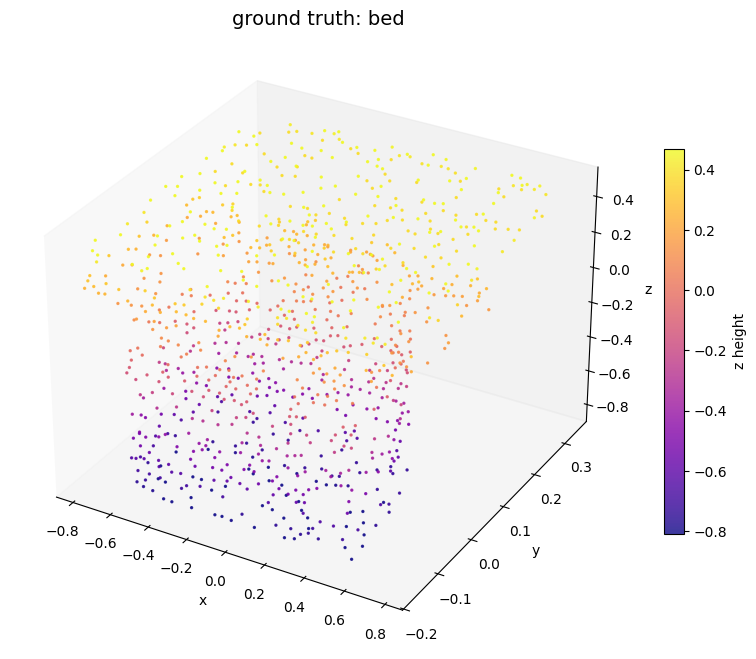

In [9]:
idx = 30
pts, label = dataset[idx]
class_name = dataset.classes[label.item()]

print(f"sample {idx}: class = {class_name} (label {label.item()})")
print(f"points shape: {pts.shape}")
print(f"xyz range — x: [{pts[:,0].min():.2f}, {pts[:,0].max():.2f}]  "
      f"y: [{pts[:,1].min():.2f}, {pts[:,1].max():.2f}]  "
      f"z: [{pts[:,2].min():.2f}, {pts[:,2].max():.2f}]")

plot_cloud(pts.numpy(), title=f"ground truth: {class_name}", color_by="z")

#### prediction using trained model

In [10]:

ckpt_path = "../checkpoints/pointnet_cls_best.pth"

model = PointNetCls(num_classes=40, feature_transform=True).to(device)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

print(f"loaded checkpoint from epoch {ckpt['epoch']} " f"(test accuracy: {ckpt['test_acc']*100:.1f}%)\n")

with torch.no_grad():
    pts_batch = pts.unsqueeze(0).to(device) # [1, 1024, 3]
    logits, _ = model(pts_batch) # [1, 40]
    probs = torch.softmax(logits, dim=1)[0] # [40]
    top_5 = probs.topk(5)
    
print(f"ground truth : {class_name}\n")
print(f"top 5 predictions: ")
for prob, idx in zip(top_5.values, top_5.indices):
    highlight_marker = "<-" if dataset.classes[idx] == class_name else ""
    print(f"{dataset.classes[idx]:20s}  {prob.item()*100:.1f}%  {highlight_marker}")

loaded checkpoint from epoch 3 (test accuracy: 0.1%)

ground truth : bed

top 5 predictions: 
airplane              52.9%  
bed                   41.2%  <-
sofa                  1.7%  
sink                  1.1%  
table                 0.7%  
